In [12]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation, NMF

nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [35]:
file_path = "/rows.csv"

complaints_raw = pd.read_csv(
    file_path,
    low_memory=False
)

complaints_raw.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [36]:
print("Rows and columns:", complaints_raw.shape)

print("\nColumn names:")
print(complaints_raw.columns.tolist())

complaints_raw.info()

Rows and columns: (1282355, 18)

Column names:
['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1282355 entries, 0 to 1282354
Data columns (total 18 columns):
 #   Column                        Non-Null Count    Dtype 
---  ------                        --------------    ----- 
 0   Date received                 1282355 non-null  object
 1   Product                       1282355 non-null  object
 2   Sub-product                   1047189 non-null  object
 3   Issue                         1282355 non-null  object
 4   Sub-issue                     751169 non-null   object
 5   Consumer complaint narrative  383564 non-null   object
 6   Company public response      

In [37]:
text_col = "Consumer complaint narrative"

complaints = complaints_raw[[text_col]].copy()

complaints = complaints.dropna()
complaints = complaints.drop_duplicates()

complaints = complaints.sample(30000, random_state=10)

print("Remaining complaints:", len(complaints))

complaints.head()

Remaining complaints: 30000


,Consumer complaint narrative
692157,I checked my credit report today and found a c...
132013,I received two unsolicited emails on XX/XX/XXX...
169610,I am consistently receiving bills to make paym...
413763,"My name is XXXX XXXX, I 'm a resident of XXXX ..."
860305,Eos cca contacted me by phone saying that I ha...


In [38]:
english_stopwords = set(stopwords.words("english"))
word_cleaner = WordNetLemmatizer()

def prepare_complaint_text(sentence):
    sentence = str(sentence).lower()
    sentence = re.sub(r"[^a-zA-Z\s]", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()

    tokens = sentence.split()

    useful_tokens = []

    for token in tokens:
        if token not in english_stopwords and len(token) > 2:
            useful_tokens.append(word_cleaner.lemmatize(token))

    return " ".join(useful_tokens)

In [39]:
complaints["clean_complaint"] = complaints[text_col].apply(prepare_complaint_text)

complaints = complaints[complaints["clean_complaint"].str.len() > 20]

complaints[[text_col, "clean_complaint"]].head()

,Consumer complaint narrative,clean_complaint
692157,I checked my credit report today and found a c...,checked credit report today found collection i...
132013,I received two unsolicited emails on XX/XX/XXX...,received two unsolicited email xxxx pay pal fi...
169610,I am consistently receiving bills to make paym...,consistently receiving bill make payment loan ...
413763,"My name is XXXX XXXX, I 'm a resident of XXXX ...",name xxxx xxxx resident xxxx xxxx xxxx effecte...
860305,Eos cca contacted me by phone saying that I ha...,eos cca contacted phone saying debt xxxx asked...


In [40]:
word_count_vectorizer = CountVectorizer(
    max_features=1200,
    min_df=5,
    max_df=0.85
)

word_count_matrix = word_count_vectorizer.fit_transform(complaints["clean_complaint"])

print("Word Count Matrix:", word_count_matrix.shape)

Word Count Matrix: (29955, 1200)


In [41]:
importance_vectorizer = TfidfVectorizer(
    max_features=1200,
    min_df=5,
    max_df=0.85
)

tfidf_matrix = importance_vectorizer.fit_transform(complaints["clean_complaint"])

print("TF-IDF Matrix:", tfidf_matrix.shape)

TF-IDF Matrix: (29955, 1200)


In [42]:
def show_topic_words(model, vocabulary, top_n=10):
    for number, topic in enumerate(model.components_, start=1):
        strongest_words = topic.argsort()[-top_n:][::-1]
        words = [vocabulary[i] for i in strongest_words]
        print(f"Topic {number}: {', '.join(words)}")

In [43]:
lda_matrix = word_count_matrix

In [44]:
lda_topics = LatentDirichletAllocation(
    n_components=5,
    random_state=10,
    learning_method="online",
    max_iter=3,
    batch_size=64
)

lda_topics.fit(lda_matrix)

count_vocabulary = word_count_vectorizer.get_feature_names_out()

print("LDA topics:")
show_topic_words(lda_topics, count_vocabulary)

LDA topics:
Topic 1: xxxx, payment, loan, mortgage, month, late, interest, year, due, paid
Topic 2: account, credit, card, bank, charge, fee, balance, one, transaction, closed
Topic 3: document, property, sale, request, home, law, state, complaint, bank, offer
Topic 4: xxxx, told, would, call, called, said, time, back, received, phone
Topic 5: xxxx, credit, report, account, debt, information, reporting, collection, letter, company


In [45]:
nmf_topics = NMF(
    n_components=5,
    random_state=10,
    init="nndsvda",
    max_iter=400
)

nmf_topics.fit(tfidf_matrix)

tfidf_vocabulary = importance_vectorizer.get_feature_names_out()

print("NMF topics:")
show_topic_words(nmf_topics, tfidf_vocabulary)

NMF topics:
Topic 1: xxxx, inquiry, date, address, name, following, letter, number, filed, received
Topic 2: account, bank, card, told, money, would, check, call, charge, fee
Topic 3: credit, report, account, reporting, information, equifax, bureau, inquiry, removed, experian
Topic 4: debt, collection, company, letter, call, agency, collect, owe, validation, received
Topic 5: payment, loan, mortgage, late, month, interest, pay, year, time, would


In [46]:
print("Comparison:")
print("CountVectorizer better for LDA because it uses word frequency.")
print("TF-IDF good for NMF, highlights specific words.")
print("LDA more topics,NMF gives clearer word groups.")

Comparison:
CountVectorizer better for LDA because it uses word frequency.
TF-IDF good for NMF, highlights specific words.
LDA more topics,NMF gives clearer word groups.


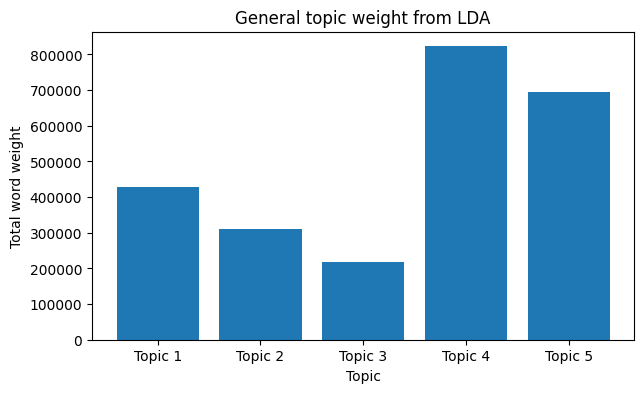

In [47]:
lda_strength = lda_topics.components_.sum(axis=1)

plt.figure(figsize=(7, 4))
plt.bar([f"Topic {i}" for i in range(1, 6)], lda_strength)
plt.title("General topic weight from LDA")
plt.xlabel("Topic")
plt.ylabel("Total word weight")
plt.show()

### Short discussion

The dataset was cleaned and prepared for NLP analysis.

- CountVectorizer was used for word frequency representation.
- TF-IDF was used to identify more relevant terms.
- LDA extracted general topic structures.
- NMF generated more focused topic groups.

Both models identified recurring complaint themes related to financial products, payments, accounts, and credit issues.